<a href="https://colab.research.google.com/github/SydAt1/Eye_Disease_Classification/blob/main/notebooks/eye_disease_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('NHIS_eye_dataset.csv')
df.sample(5)

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Category,Question,Response,Age,...,ResponseID,DataValueTypeID,AgeID,SexID,RaceEthnicityID,RiskFactorID,RiskFactorResponseID,GeoLocation,Geographic Level,StateAbbreviation
29678,2016,2017,US,National,NHIS,Visual Function,Visual Field,Percentage of adults who even when wearing gla...,Very difficult,65-84 years,...,RVD,CRDPREV,AGE6584,GF,WHT,RFHT,RFNO,NaN,National,US
48301,2016,2017,US,National,NHIS,Visual Function,Near-Distance Visual Function,Percentage of adults who when wearing glasses ...,Not at all difficult,18-39 years,...,RNOTD,CRDPREV,AGE1839,GF,OTH,RFHT,RFYES,NaN,National,US
45585,2016,2017,US,National,NHIS,Visual Function,Near-Distance Visual Function,Percentage of adults who when wearing glasses ...,Can't do at all because of eyesight,18 years and older,...,RCNTE,CRDPREV,AGE18PLUS,GF,ALLRACE,RFSM,RFNEV,NaN,National,US
35642,2016,2017,US,National,NHIS,Visual Function,Difficulty Finding Objects,Percentage of adults who even when wearing gla...,Refused,85 years and older,...,RRF,CRDPREV,AGE85PLUS,GM,ASN,RFDM,RFBD,NaN,National,US
49077,2016,2017,US,National,NHIS,Visual Function,Near-Distance Visual Function,Percentage of adults who when wearing glasses ...,Not at all difficult,85 years and older,...,RNOTD,CRDPREV,AGE85PLUS,GF,OTH,RFHT,RFNO,NaN,National,US


## 1. Data Exploration

Simply removing all the Null values here can result in wiping a large portion of rows of the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71649 entries, 0 to 71648
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   YearStart                   71649 non-null  int64  
 1   YearEnd                     71649 non-null  int64  
 2   LocationAbbr                71649 non-null  object 
 3   LocationDesc                71649 non-null  object 
 4   DataSource                  71649 non-null  object 
 5   Topic                       71649 non-null  object 
 6   Category                    71649 non-null  object 
 7   Question                    71649 non-null  object 
 8   Response                    71649 non-null  object 
 9   Age                         71649 non-null  object 
 10  Sex                         71649 non-null  object 
 11  RaceEthnicity               71649 non-null  object 
 12  RiskFactor                  71649 non-null  object 
 13  RiskFactorResponse          716

In [4]:
# Drop columns that have zero data
df = df.drop(columns=['Numerator', 'GeoLocation'])

In [5]:
df.isna().sum()

,0
YearStart,0
YearEnd,0
LocationAbbr,0
LocationDesc,0
DataSource,0
Topic,0
Category,0
Question,0
Response,0
Age,0


In [6]:
# Drop rows only if the actual results (Data_Value) are missing
df_model = df.dropna(subset=['Data_Value']).copy()

### 1.1 Target Distribution (Data_Value)

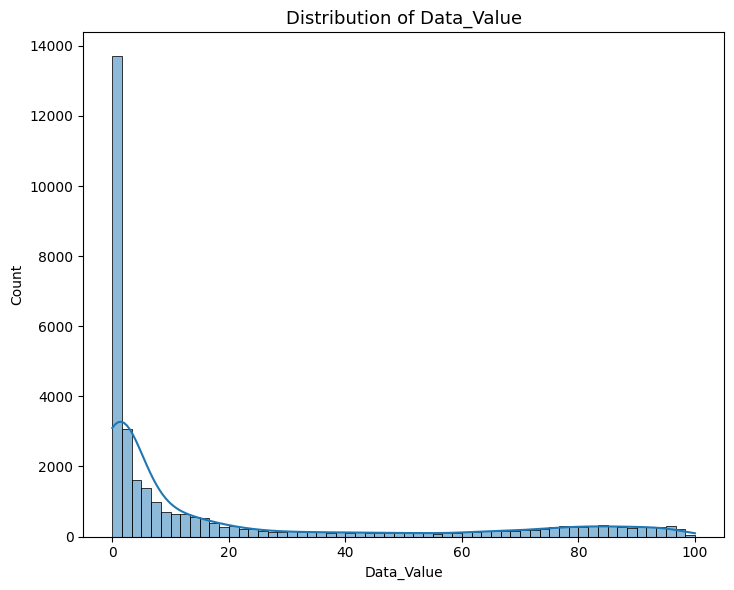

In [20]:
plt.figure(figsize=(14, 6))

# Histogram + KDE
plt.subplot(1,2,1)
sns.histplot(data=df, x='Data_Value', bins=60, kde=True)
plt.title('Distribution of Data_Value', fontsize=13)

plt.tight_layout()
plt.show()

### 1.2 Top Questions – Prevalence & Distribution

/tmp/ipython-input-2053591123.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


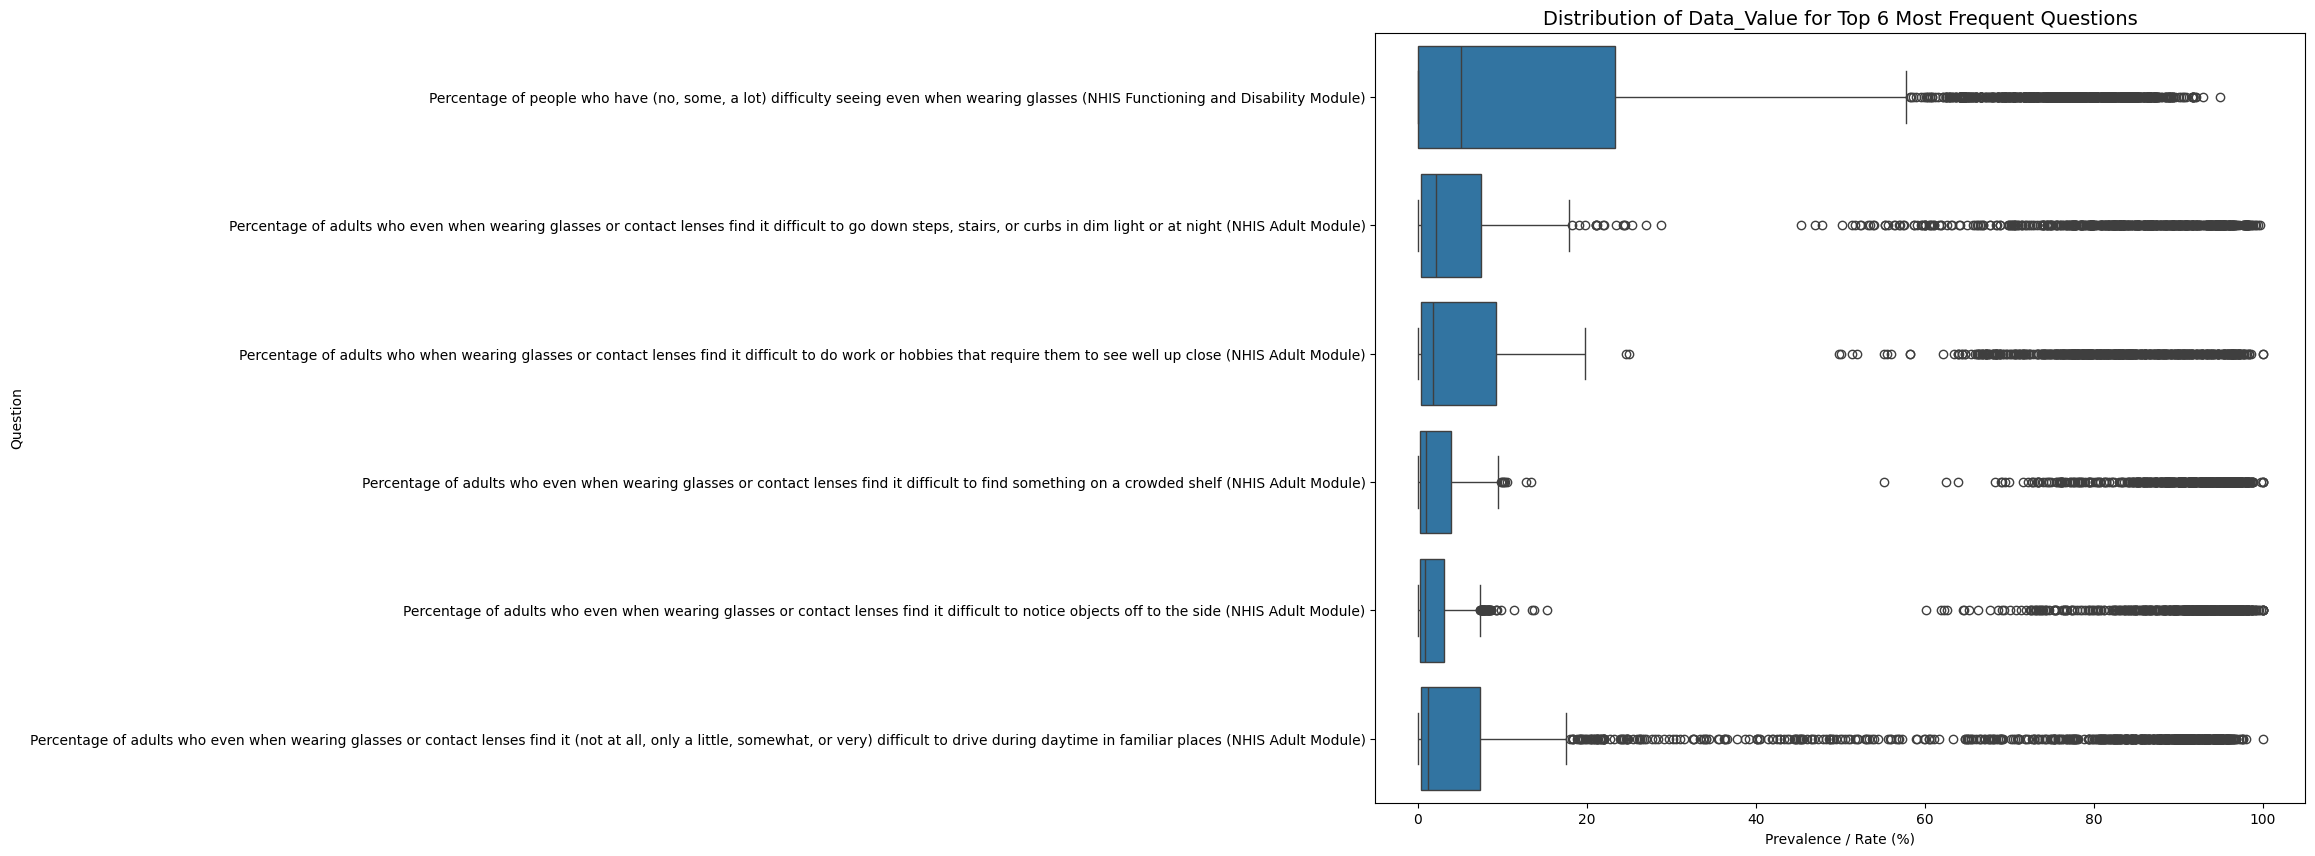

In [18]:
# Most common questions
top_questions = df['Question'].value_counts().head(6).index

plt.figure(figsize=(12, 10))

sns.boxplot(data=df[df['Question'].isin(top_questions)],
            y='Question', x='Data_Value',
            order=top_questions)

plt.title('Distribution of Data_Value for Top 6 Most Frequent Questions', fontsize=14)
plt.xlabel('Prevalence / Rate (%)')
plt.tight_layout()
plt.show()

### 1.3 Data_Value Distribution By Age

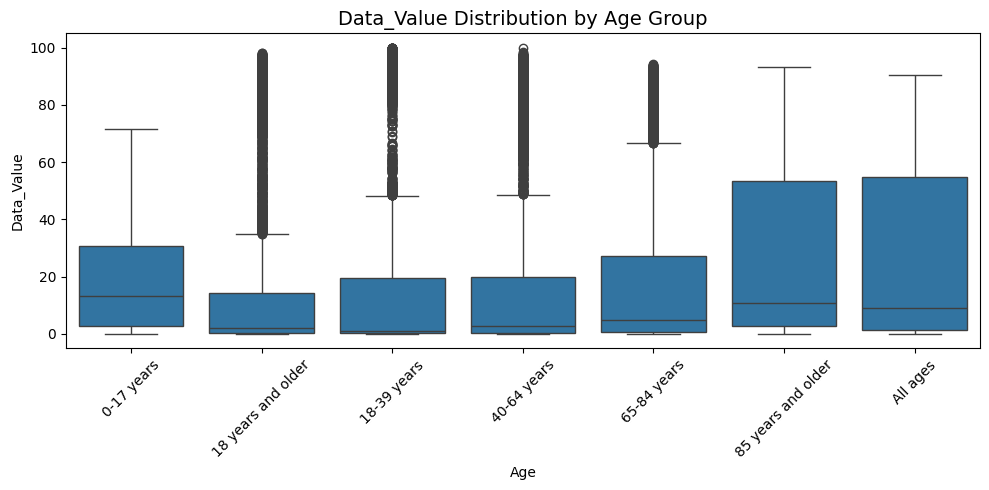

In [13]:
#  Age groups
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Age', y='Data_Value', order=sorted(df['Age'].unique()))
plt.title('Data_Value Distribution by Age Group', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### 1.4 Time Trend – Overall & by Category

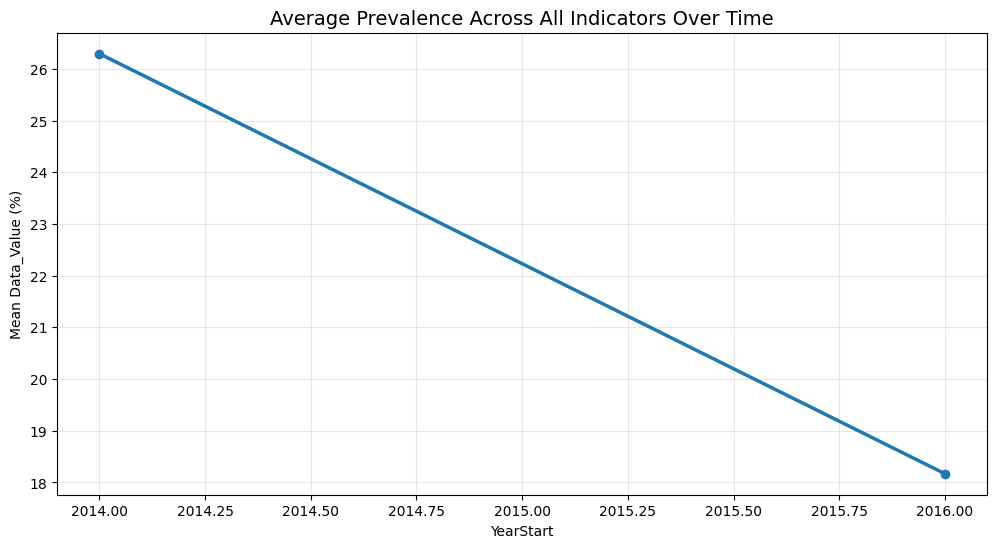

In [16]:
# Overall trend
year_trend = df.groupby('YearStart')['Data_Value'].mean()

plt.figure(figsize=(12, 6))
year_trend.plot(marker='o', linewidth=2.5)
plt.title('Average Prevalence Across All Indicators Over Time', fontsize=14)
plt.ylabel('Mean Data_Value (%)')
plt.grid(True, alpha=0.3)
plt.show()

### 1.5 Trend by Topic (top topics)

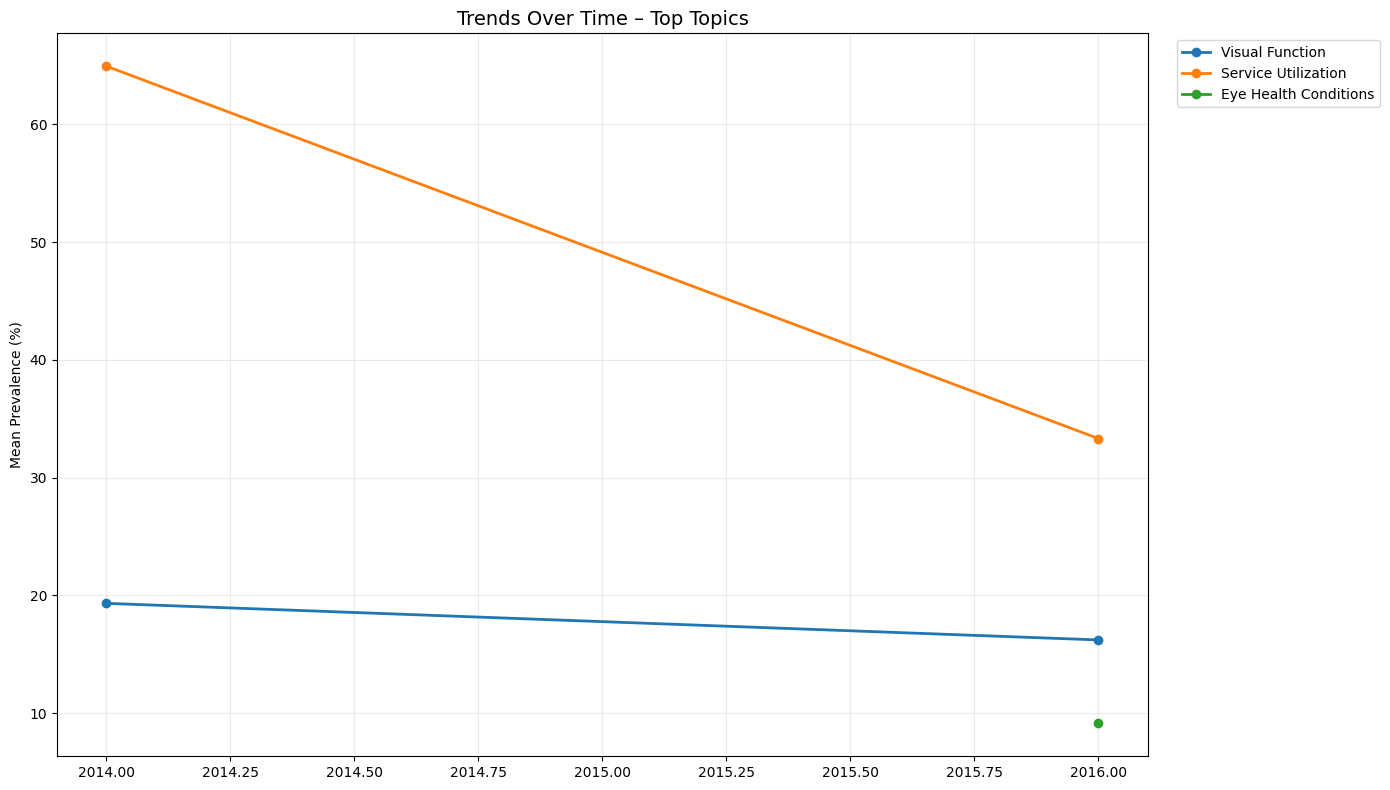

In [17]:
# Trend by Topic (top topics)
top_topics = df['Topic'].value_counts().head(6).index

plt.figure(figsize=(14, 8))
for topic in top_topics:
    data = df[df['Topic'] == topic].groupby('YearStart')['Data_Value'].mean()
    plt.plot(data.index, data.values, marker='o', label=topic, linewidth=2)

plt.title('Trends Over Time – Top Topics', fontsize=14)
plt.ylabel('Mean Prevalence (%)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Data Correlation

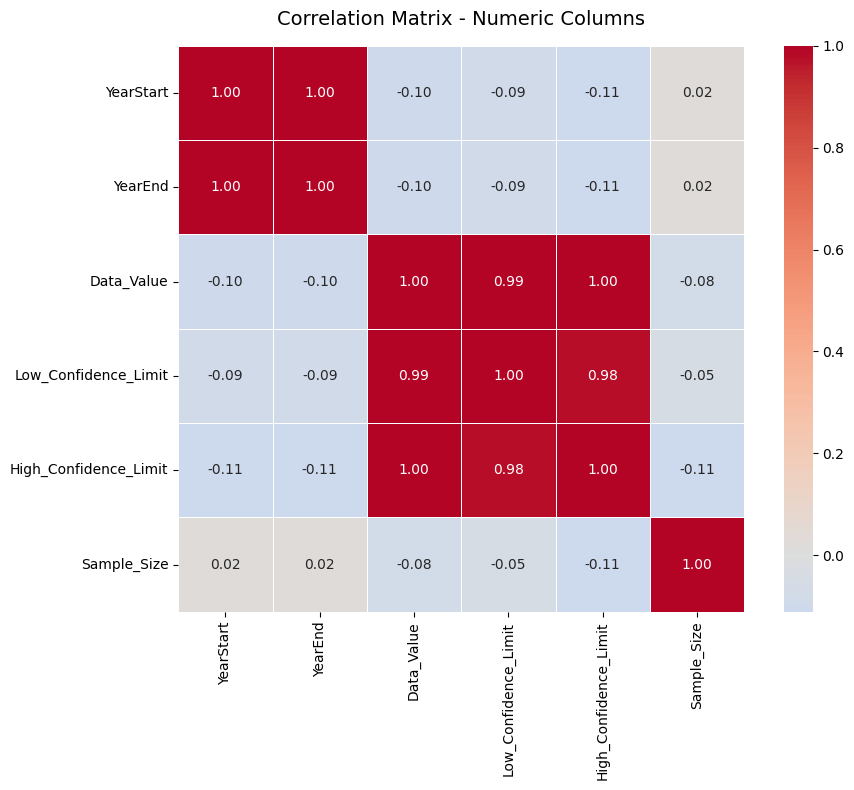

In [21]:
# Select only numeric columns that actually have values
numeric_cols = ['YearStart', 'YearEnd', 'Data_Value', 'Low_Confidence_Limit',
                'High_Confidence_Limit', 'Sample_Size']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix - Numeric Columns', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

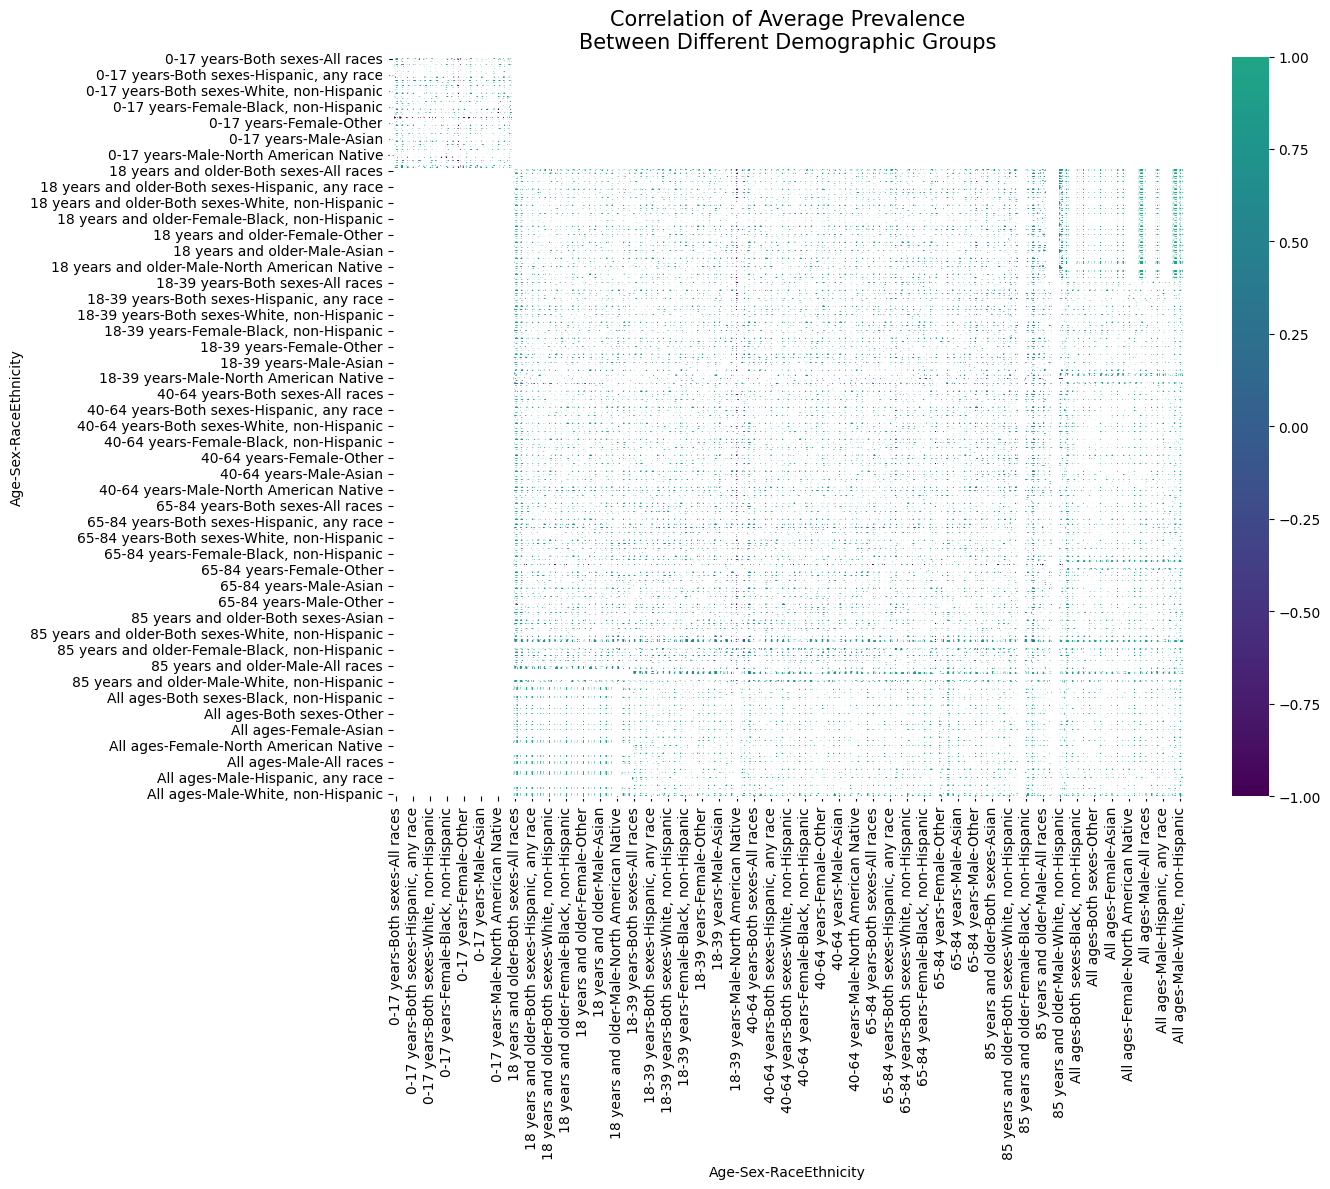

In [22]:
# Create a summary table: mean Data_Value per combination of stratifications
pivot_correlation = df.pivot_table(
    values='Data_Value',
    index=['Topic', 'Question'],
    columns=['Age', 'Sex', 'RaceEthnicity'],
    aggfunc='mean',
    observed=False
)

# Compute correlation between different stratifications (across questions)
corr_strat = pivot_correlation.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_strat, annot=True, fmt='.2f', cmap='viridis',
            linewidths=0.4, center=0.7)
plt.title('Correlation of Average Prevalence\nBetween Different Demographic Groups', fontsize=15)
plt.tight_layout()
plt.show()

1. What is Data_Value?

The Data_Value column is the primary metric of this dataset. It represents the statistical result for a specific survey question (e.g., "Difficulty seeing even when wearing glasses").

  * Type: Usually a percentage (Prevalence) or a crude rate.

  * Context: It must be interpreted alongside Data_Value_Unit (%) and Data_Value_Type (e.g., Age-adjusted Prevalence).

In [ ]:
# To see all unique footnotes in the dataset
df_model['Data_Value'].unique()

array([ 2.74,  2.34,  5.25, ..., 48.5 , 46.5 , 39.6 ])

The target variable `Data_Value` represents the prevalence of eye disease at a population level. The model uses demographic factors, risk factors, geographic location, and temporal information to predict variations in eye disease prevalence.

In [ ]:
df_model.shape[0]

11295

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11295 entries, 0 to 23740
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   YearStart                   11295 non-null  int64  
 1   YearEnd                     11295 non-null  int64  
 2   LocationAbbr                11295 non-null  object 
 3   LocationDesc                11295 non-null  object 
 4   DataSource                  11295 non-null  object 
 5   Topic                       11295 non-null  object 
 6   Category                    11295 non-null  object 
 7   Question                    11295 non-null  object 
 8   Response                    11295 non-null  object 
 9   Age                         11295 non-null  object 
 10  Sex                         11295 non-null  object 
 11  RaceEthnicity               11295 non-null  object 
 12  RiskFactor                  11295 non-null  object 
 13  RiskFactorResponse          11295 no

## 2. Data Cleaning

In [23]:
# Remove the columns that aren't 'features' (like footnotes or empty columns)
cols_to_keep = ['YearStart', 'LocationAbbr', 'Age', 'Sex', 'RaceEthnicity', 'Question', 'Data_Value', 'RiskFactorID', 'RiskFactorResponseID']
df_model = df_model[cols_to_keep]

To predict prevalence or health outcomes, we need a mix of demographics (who they are), geography (where they are), and medical context (what other risks they have).

Here is why the selected columns are the "Engine" of the Machine Learning model:

#### The Target Variable

* Data_Value: This is the Label. It is the specific percentage or rate which is to be predicted. Without this, the model has no "answer key" to learn from.

#### The Features (Predictors)
* Age, Sex, RaceEthnicity: These are the Primary Biological Predictors. Most eye conditions (like cataracts or macular degeneration) are heavily dependent on age and sometimes vary significantly by gender or genetic background.

* RiskFactorID & RiskFactorResponseID: These are the Clinical Predictors. Conditions like Diabetes or Smoking status are high-impact drivers of eye health. These columns tell the model why a certain group might have higher vision loss than another group of the same age.

* Question: This is the Context Feature. Since your dataset contains multiple types of eye conditions, this tells the model which specific condition the Data_Value refers to.

* LocationAbbr: This is the Environmental Predictor. It captures geographic disparities, such as differences in state-level healthcare access or regional environmental factors.

* YearStart: This is the Temporal Predictor. It helps the model account for trends over time, such as improvements in medical technology or changes in survey methods.

In [25]:
df_model.sample(5)

,YearStart,LocationAbbr,Age,Sex,RaceEthnicity,Question,Data_Value,RiskFactorID,RiskFactorResponseID
61498,2014,US,40-64 years,Female,"White, non-Hispanic",Percentage of adults who are blind or unable t...,2.4,RFHT,RFTOT
62249,2014,US,All ages,Male,"Black, non-Hispanic",Percentage of adults who are blind or unable t...,5.3,RFDM,RFNO
64526,2014,US,All ages,Female,Asian,"Percentage of people who have (no, some, a lot...",0.0,RFHT,RFNO
60975,2014,US,65-84 years,Male,Asian,Percentage of people who wear glasses (NHIS Fu...,85.8,RFHT,RFYES
62812,2014,US,65-84 years,Both sexes,All races,Percentage of adults who have trouble seeing e...,13.0,RFSM,RFTOT


## 3. Data Preparation

### 3.1 Encoding

In [33]:
df = df_model

In [34]:
df['Age'].unique()

array(['40-64 years', '65-84 years', '18-39 years', 'All ages',
       '18 years and older', '85 years and older', '0-17 years'],
      dtype=object)

Age -> Ordinal Encoding

In [35]:
age_map = {
    '0-17 years': 0,
    '18-39 years': 1,
    '40-64 years': 2,
    '65-84 years': 3,
    '85 years and older': 4,
    '18 years and older': 5,
    'All ages': 6
}

df['Age_range'] = df['Age'].map(age_map)

Sex -> Encoding

In [36]:
# Encoding for Sex
sex_map = {'Male': 0, 'Female': 1, 'Both sexes': 2}
df['Sex'] = df['Sex'].map(sex_map)

Nominal Categorical Columns -> Label Encoding (Prep Stage)

Columns:

* LocationAbbr

* RaceEthnicity

* Question

* RiskFactorID

* RiskFactorResponseID

In [37]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'LocationAbbr',
    'RaceEthnicity',
    'Question',
    'RiskFactorID',
    'RiskFactorResponseID'
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

All the locations present in the dataset are from the same place. So dropping this column

In [39]:
df.drop(columns=['LocationAbbr'], inplace=True)

### 3.2 Risk Level

Convert Data_Value into classes

Converting a continuous risk value into categorical risk classes, in order to use the data for classification models.

In [42]:
def risk_class_numeric(value):
    if value <= 7:
        return 0
    elif value <= 31:
        return 1
    elif value <= 70:
        return 2
    else:
        return 3

df["Risk_Level"] = df["Data_Value"].apply(risk_class_numeric)

In [43]:
df.drop(columns=['Age'], inplace=True)

In [ ]:
df.to_csv("prepped_NHIS_dataset.csv")

## 4. Logistic Regression Model Training

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [195]:
df = pd.read_csv("prepped_NHIS_dataset.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)

In [196]:
print("Dataset shape:", df.shape)
print("Risk level distribution:\n", df["Risk_Level"].value_counts())

Dataset shape: (11295, 9)
Risk level distribution:
 Risk_Level
0    5642
1    2856
2    1900
3     897
Name: count, dtype: int64


In [50]:
original = df

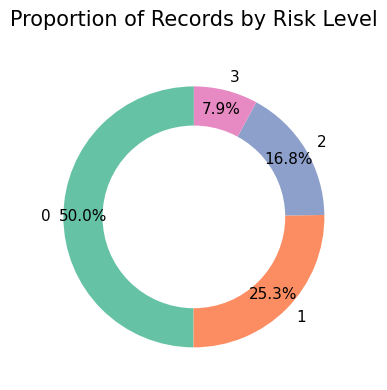

In [82]:
plt.figure(figsize=(4, 4))

risk_counts = df['Risk_Level'].value_counts()

plt.pie(risk_counts.values,
        labels=risk_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(risk_counts)),
        startangle=90,
        pctdistance=0.85,
        textprops={'fontsize': 11})

# Add a white circle in the middle (donut style)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proportion of Records by Risk Level', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

#### 4.1 Features and Target & Train/Test Split

In [83]:
# PREPARE FEATURES & TARGET
feature_cols = [col for col in df.columns if col not in ["Data_Value", "Risk_Level"]]

X = df[feature_cols]
y = df["Risk_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y  # IMPORTANT for class balance
)

#### 4.2 Training and Fitting Data into the Logistic Regression Pipeline

In [84]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=1000,
        n_jobs=-1
    ))
])

logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    n_jobs=-1))])

#### 4.3 Predictions

In [85]:
y_train_pred = logreg_pipeline.predict(X_train)
y_test_pred = logreg_pipeline.predict(X_test)

#### 4.4 Evaluation Metrics

In [86]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [87]:
# Performance Metrics

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}\n")

print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 0.7415
Test Accuracy:     0.7250

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      1693
           1       0.66      0.72      0.69       857
           2       0.66      0.42      0.52       570
           3       0.26      0.07      0.11       269

    accuracy                           0.72      3389
   macro avg       0.59      0.54      0.54      3389
weighted avg       0.69      0.72      0.69      3389



72% Accuracy, so lets try to up those numbers.

#### 4.5 Hyperparamter Tuning

In [88]:
df.head()

,YearStart,Sex,Data_Value,Age_range,RaceEthnicity_Asian,"RaceEthnicity_Black, non-Hispanic","RaceEthnicity_Hispanic, any race",RaceEthnicity_North American Native,RaceEthnicity_Other,"RaceEthnicity_White, non-Hispanic",...,RiskFactorID_RFDM,RiskFactorID_RFHT,RiskFactorID_RFSM,RiskFactorResponseID_RFCURR,RiskFactorResponseID_RFFORM,RiskFactorResponseID_RFNEV,RiskFactorResponseID_RFNO,RiskFactorResponseID_RFTOT,RiskFactorResponseID_RFYES,Risk_Level
0,2016,0,2.74,2,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,0
1,2016,0,2.34,2,False,False,False,False,False,True,...,True,False,False,False,False,False,True,False,False,0
2,2016,0,5.25,2,False,False,False,False,False,True,...,True,False,False,False,False,False,False,False,True,0
3,2016,0,1.90,2,False,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,0
4,2016,0,4.02,2,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,True,0


In [89]:
import warnings
warnings.filterwarnings("ignore")

In [90]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "logreg__C": [0.01, 0.1, 1, 3, 10]
}

grid = GridSearchCV(
    logreg_pipeline,
    param_grid,
    scoring="balanced_accuracy",
    cv=5
)

grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("CV Balanced Accuracy:", grid.best_score_)


Best C: {'logreg__C': 0.1}
CV Balanced Accuracy: 0.5538278433566067


In [91]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=0.1,
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    ))
])
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=2000, n_jobs=-1))])

In [92]:
y_train_pred = logreg_pipeline.predict(X_train)
y_test_pred = logreg_pipeline.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [93]:
# Performance Metrics

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}\n")

print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 0.6180
Test Accuracy:     0.6046

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.61      0.71      1693
           1       0.64      0.73      0.68       857
           2       0.59      0.37      0.45       570
           3       0.22      0.68      0.33       269

    accuracy                           0.60      3389
   macro avg       0.57      0.60      0.54      3389
weighted avg       0.70      0.60      0.63      3389



Since the performance degraded even more:
* Define soft class weight candidates

In [94]:
class_weight_grid = [
    {0:1, 1:1,   2:1,   3:1},      # baseline
    {0:1, 1:1.1, 2:1.2, 3:1.4},
    {0:1, 1:1.2, 2:1.4, 3:1.8},
    {0:1, 1:1.3, 2:1.6, 3:2.2},
    {0:1, 1:1.5, 2:2.0, 3:3.0},    # close to balanced
]

In [95]:
param_grid = {
    "logreg__C": [0.1, 0.3, 1, 3],
    "logreg__class_weight": class_weight_grid
}

grid = GridSearchCV(
    logreg_pipeline,
    param_grid,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV balanced accuracy:", grid.best_score_)

Best params: {'logreg__C': 1, 'logreg__class_weight': {0: 1, 1: 1.5, 2: 2.0, 3: 3.0}}
Best CV balanced accuracy: 0.5960078523314511


In [96]:
best_pipeline = grid.best_estimator_

y_test_pred = best_pipeline.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.7010917674830334
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1693
           1       0.65      0.73      0.69       857
           2       0.66      0.39      0.49       570
           3       0.30      0.40      0.35       269

    accuracy                           0.70      3389
   macro avg       0.61      0.59      0.59      3389
weighted avg       0.71      0.70      0.70      3389



The class "3" which is the high risk class is severely underpresented

Going to merge the 2 and 3 classes so we will have:

* 0 - Low risk

* 1 - Medium risk

* 2 - High risk

* 3 - High Risk (Merged with 2)

Initial experiments with four risk categories showed severe confusion between higher risk levels, particularly Risk_Level 2 and 3. As these categories represent similar clinical severity, they were merged into a single high-risk class, resulting in improved class balance and more reliable predictive performance.

#### 4.6 Merged Training/Evaluation

In [138]:
df.head()

,YearStart,Sex,RaceEthnicity,Question,Data_Value,RiskFactorID,RiskFactorResponseID,Age_range,Risk_Level,Risk_Level_3
0,2016,0,6,8,2.74,0,5,2,0,0
1,2016,0,6,8,2.34,1,4,2,0,0
2,2016,0,6,8,5.25,1,6,2,0,0
3,2016,0,6,8,1.90,2,4,2,0,0
4,2016,0,6,8,4.02,2,6,2,0,0


In [144]:
df["Risk_Level_3"] = df["Risk_Level"].replace({3: 2})

print(df["Risk_Level_3"].value_counts())

Risk_Level_3
0    5642
1    2856
2    2797
Name: count, dtype: int64


In [141]:
X = df[feature_cols]
y = df["Risk_Level_Merged"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [100]:
class_weight = {
    0: 1,
    1: 1.2,
    2: 1.6
}

In [101]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        C=0.01,
        class_weight=class_weight,
        max_iter=4000,
        n_jobs=-1
    ))
])

logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=0.01, class_weight={0: 1, 1: 1.2, 2: 1.6},
                                    max_iter=4000, multi_class='multinomial',
                                    n_jobs=-1))])

In [102]:
y_pred = logreg_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7624668043670699
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      1693
           1       0.67      0.70      0.68       857
           2       0.80      0.50      0.62       839

    accuracy                           0.76      3389
   macro avg       0.75      0.71      0.72      3389
weighted avg       0.76      0.76      0.75      3389

[[1562  105   26]
 [ 175  602   80]
 [ 225  194  420]]


##### 4.6.1 Confusion Matrix Heat Map

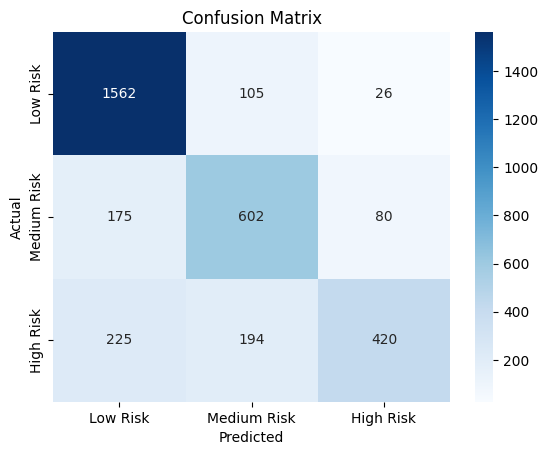

In [106]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Low Risk', 'Medium Risk', 'High Risk'],
            yticklabels=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The logistic regression model does well on Low Risk cases but misses many High Risk ones (only ~50% correctly identified). This under-representation of high-risk cases is a serious concern.
Switching to Random Forest is a good next step. It's a stronger model that usually performs better on imbalanced data, captures more complex patterns, and is less likely to overlook the minority High Risk class. You can also easily improve it further by using class weights or adjusting other parameters.

## 5. Random Forest Classifier

### 5.1 Train Test Split

In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

In [111]:
feature_cols = [c for c in df.columns if c not in ["Data_Value", "Risk_Level", "Age"]]

X = df[feature_cols]
y = df["Risk_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


### 5.2 Model Training

In [114]:
# Trainig Random Forest Classifier

rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,          # let trees grow, forest will regularize
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [115]:
# PREDICTIONS
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)


### 5.3 Model Evaluation

In [116]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")
print(f"Balanced Test Accuracy:  {balanced_acc:.4f}\n")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Training Accuracy:       0.8272
Test Accuracy:           0.6822
Balanced Test Accuracy:  0.6105

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.84      0.72      0.77      1693
           1       0.72      0.74      0.73       857
           2       0.66      0.64      0.65       570
           3       0.18      0.34      0.24       269

    accuracy                           0.68      3389
   macro avg       0.60      0.61      0.60      3389
weighted avg       0.73      0.68      0.70      3389



Trying to improve model performance

In [117]:
rf_clf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=4,
    # class_weight={0:1, 1:1.2, 2:1.8, 3:4}, # Accuracy with this weight was 0.76
    class_weight={0:1, 1:1.2, 2:1.5, 3:3}, #this was giving 0.78 accuracy
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 1.2, 2: 1.5, 3: 3}, max_depth=12,
                       min_samples_leaf=4, n_estimators=600, n_jobs=-1,
                       random_state=42)

In [118]:
# PREDICTIONS
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)

In [119]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Training Accuracy:       0.7743
Test Accuracy:           0.7495
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.76      0.95      0.85      1693
           1       0.70      0.70      0.70       857
           2       0.84      0.43      0.57       570
           3       0.62      0.32      0.42       269

    accuracy                           0.75      3389
   macro avg       0.73      0.60      0.64      3389
weighted avg       0.75      0.75      0.73      3389



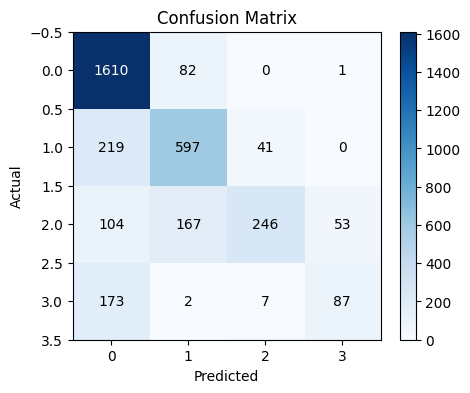

In [120]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot the Confusion Matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

# Add numbers in the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='black' if cm[i, j] < cm.max()/2 else 'white')

plt.show()

The model performs well for low and moderate visual impairment risk but shows reduced recall for very high risk, with most errors occurring between adjacent risk levels, reflecting the ordinal nature and class imbalance of the data.

In [121]:
from sklearn.utils.class_weight import compute_class_weight

# y_train is the Risk_Level labels
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict


{np.int64(0): np.float64(0.5005064573309699),
 np.int64(1): np.float64(0.988744372186093),
 np.int64(2): np.float64(1.4860902255639097),
 np.int64(3): np.float64(3.147292993630573)}

In [122]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=class_weight_dict,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight={np.int64(0): np.float64(0.5005064573309699),
                                     np.int64(1): np.float64(0.988744372186093),
                                     np.int64(2): np.float64(1.4860902255639097),
                                     np.int64(3): np.float64(3.147292993630573)},
                       n_estimators=300, n_jobs=-1, random_state=42)

In [123]:
y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80      1693
           1       0.72      0.69      0.71       857
           2       0.62      0.66      0.64       570
           3       0.21      0.29      0.24       269

    accuracy                           0.70      3389
   macro avg       0.60      0.61      0.60      3389
weighted avg       0.72      0.70      0.71      3389



Given the strong overlap and class imbalance between high and very high visual impairment risk, these categories were merged into a single high-risk class. This improved model stability, increased severe-risk recall, and produced a more clinically meaningful risk stratification for population-level screening.

### 5.4 Merging the Classes

In [170]:
df["Risk_Level_Merged"] = df["Risk_Level"].replace({3: 2})

In [171]:
print(df["Risk_Level_Merged"].value_counts().sort_index())

Risk_Level_Merged
0    5642
1    2856
2    2797
Name: count, dtype: int64


In [172]:
feature_cols = [c for c in df.columns if c not in ["Data_Value", "Risk_Level", "Age", "Risk_Level_Merged"]]

X = df[feature_cols]
y = df["Risk_Level_Merged"]

In [152]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [153]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [154]:
y_pred = rf_clf.predict(X_test)

print("Training Accuracy:", rf_clf.score(X_train, y_train))
print("Test Accuracy:", rf_clf.score(X_test, y_test))

print("\nClassification Report (Merged Classes):")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training Accuracy: 0.8864541832669323
Test Accuracy: 0.7972554227534308

Classification Report (Merged Classes):
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1129
           1       0.72      0.72      0.72       571
           2       0.80      0.58      0.67       559

    accuracy                           0.80      2259
   macro avg       0.78      0.75      0.76      2259
weighted avg       0.79      0.80      0.79      2259


Confusion Matrix:
[[1066   49   14]
 [  90  413   68]
 [ 125  112  322]]


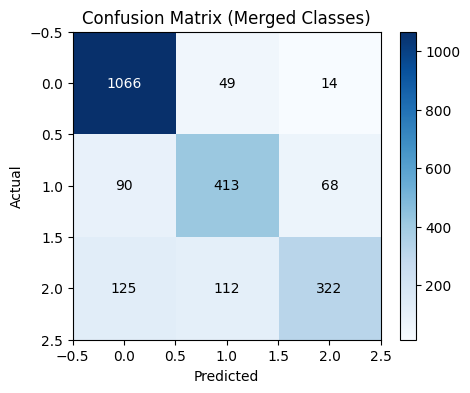

In [155]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Merged Classes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

# Add numbers in the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            color='black' if cm[i, j] < cm.max()/2 else 'white'
        )

plt.show()

Merging severe risk classes reduced instability and produced a more reliable and interpretable risk stratification.

AUC ROC Curve

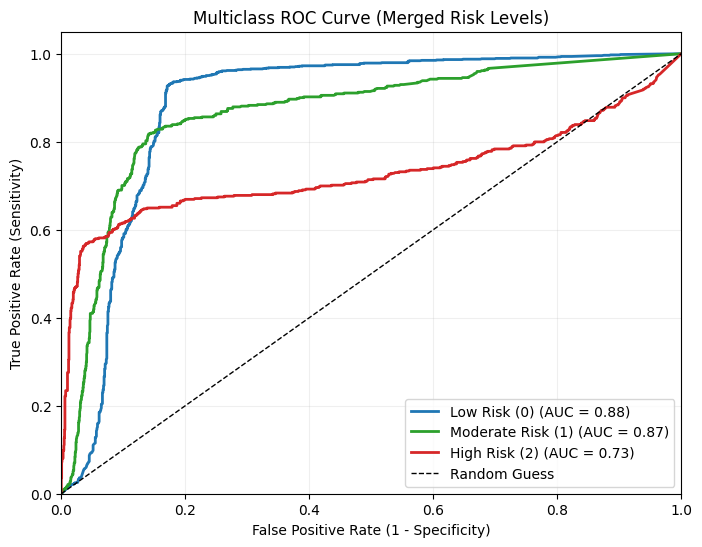

In [159]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for your 3 classes (0, 1, 2)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Get predicted probabilities (Crucial for ROC)
y_score = rf_clf.predict_proba(X_test)

# Plotting Setup
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green, Red
labels = ['Low Risk (0)', 'Moderate Risk (1)', 'High Risk (2)']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multiclass ROC Curve (Merged Risk Levels)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

The Random Forest model improved things but still missed too many high-risk cases (only ~58% caught) and in the ROC curve above it underperforms significantly as compared to Low and Moderate Risk.


Next step: XGBoost.


It learns from every mistake sequentially, focuses harder on the tough high-risk examples, and typically delivers better detection of the minority class we care about most.

## 6. XGBoost Model

### 6.1 Train/Test Split

In [163]:
from xgboost import XGBClassifier

In [161]:
X = df[feature_cols]
y = df["Risk_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

### 6.2 Training the XGBoost Model

In [164]:
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

### 6.3 Predictions

In [165]:
# PREDICTIONS
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

### 6.4 Evaluation Metrics

In [166]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"\nTraining Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")
print(f"Balanced Test Accuracy:  {balanced_acc:.4f}\n")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Training Accuracy:       0.8862
Test Accuracy:           0.8174
Balanced Test Accuracy:  0.6943

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1693
           1       0.78      0.76      0.77       857
           2       0.77      0.72      0.75       570
           3       0.78      0.34      0.48       269

    accuracy                           0.82      3389
   macro avg       0.79      0.69      0.72      3389
weighted avg       0.81      0.82      0.81      3389



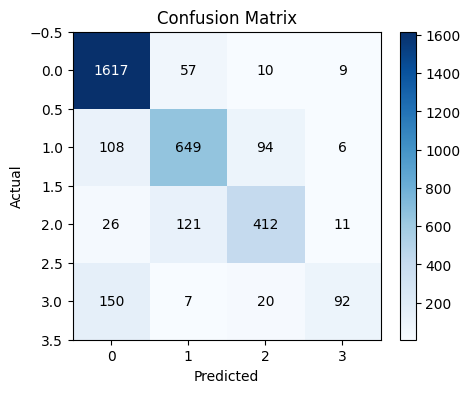

In [167]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot the Confusion Matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

# Add numbers in the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='black' if cm[i, j] < cm.max()/2 else 'white')

plt.show()

AUC Curve

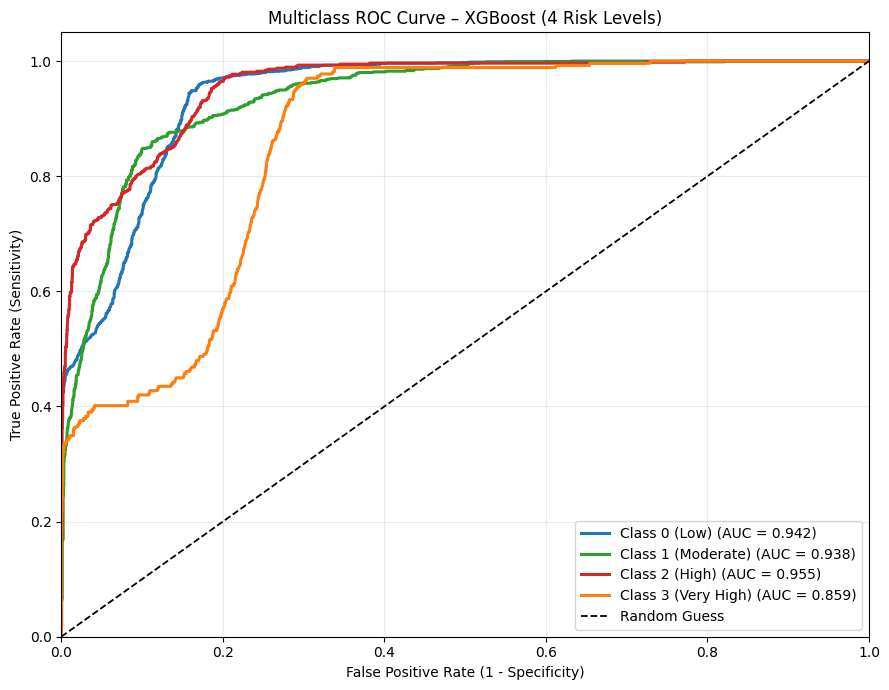

In [169]:
# Binarize the labels for 4 classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = 4

# Get predicted probabilities from XGBoost
y_score = xgb_clf.predict_proba(X_test)

# Plotting
plt.figure(figsize=(9, 7))
colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']  # Blue, Green, Red, Orange
labels = ['Class 0 (Low)', 'Class 1 (Moderate)', 'Class 2 (High)', 'Class 3 (Very High)']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2.2,
             label=f'{labels[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.3, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multiclass ROC Curve – XGBoost (4 Risk Levels)')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Class 3 is currently the weak link and the model is failing at the most critical task (catching the highest risk cases).


Merging 2 and 3 is the fastest, most practical way to dramatically improve detection of serious/high-risk cases.

### 6.5 Merging the Classes

The Merge is already in section `5.4`, so re-running that cell

In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [174]:
xgb_clf = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [175]:
# PREDICTIONS
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"\nTuned Model Results")
print(f"Training Accuracy:       {train_acc:.4f}")
print(f"Test Accuracy:           {test_acc:.4f}")
print(f"Balanced Test Accuracy:  {balanced_acc:.4f}\n")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Tuned Model Results
Training Accuracy:       0.8785
Test Accuracy:           0.8287
Balanced Test Accuracy:  0.7822

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      1129
           1       0.77      0.78      0.77       571
           2       0.85      0.60      0.70       559

    accuracy                           0.83      2259
   macro avg       0.82      0.78      0.79      2259
weighted avg       0.83      0.83      0.82      2259



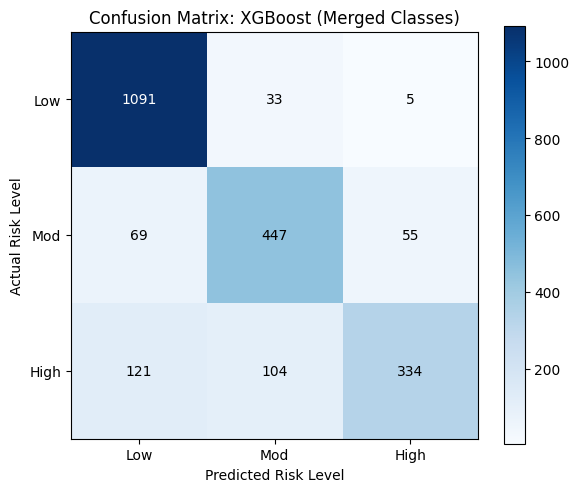

In [176]:
# Use y_test_pred (test predictions) instead of y_train_pred
cm = confusion_matrix(y_test, y_test_pred)

# Plotting
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix: XGBoost (Merged Classes)')
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
plt.colorbar()

# Define class labels for the axes (0=Low, 1=Mod, 2=High)
tick_marks = [0, 1, 2]
plt.xticks(tick_marks, ['Low', 'Mod', 'High'])
plt.yticks(tick_marks, ['Low', 'Mod', 'High'])

# 3. Add numbers in the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha='center',
            va='center',
            color='black' if cm[i, j] < cm.max()/2 else 'white'
        )

plt.tight_layout()
plt.show()

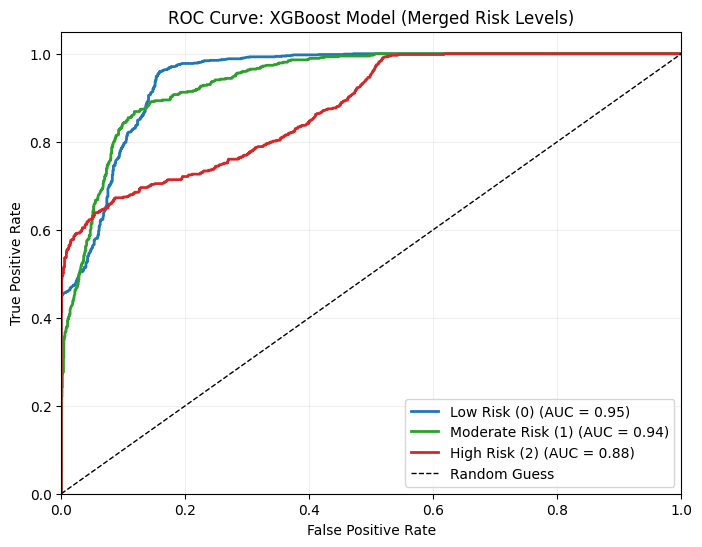

In [177]:
#  Binarize the labels for the 3 merged classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Get predicted probabilities from XGBoost
y_score = xgb_clf.predict_proba(X_test)

# Plotting
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green, Red
labels = ['Low Risk (0)', 'Moderate Risk (1)', 'High Risk (2)']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: XGBoost Model (Merged Risk Levels)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

## LIME Explanables

Doing the LIME Explanables on the best model here i.e. XGBoost

In [186]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b472989759b252aeb1abc6e554b6f80a8ae7a4b1c792457ce4c02e4275fa1fa6
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [187]:
from lime.lime_tabular import LimeTabularExplainer

# Build explainer using training data
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    class_names=["Low risk", "Moderate risk", "High risk", "Very high risk"],
    mode="classification",
    discretize_continuous=True
)


In [188]:
exp = explainer.explain_instance(
    data_row=X_input.iloc[0].values,
    predict_fn=rf_clf.predict_proba,
    num_features=8
)

print("\nWHY THIS RISK LEVEL WAS PREDICTED (LIME)\n")
for feature, weight in exp.as_list():
    direction = "increases" if weight > 0 else "decreases"
    print(f"- {feature} {direction} risk (weight={weight:.3f})")



WHY THIS RISK LEVEL WAS PREDICTED (LIME)

- Question <= 5.00 decreases risk (weight=-0.181)
- Age_range <= 2.00 decreases risk (weight=-0.103)
- 2.00 < RiskFactorID <= 3.00 decreases risk (weight=-0.016)
- YearStart > 2016.00 decreases risk (weight=-0.012)
- RiskFactorResponseID <= 3.00 increases risk (weight=0.008)
- 0.00 < Sex <= 1.00 increases risk (weight=0.006)
- RaceEthnicity <= 1.00 decreases risk (weight=-0.001)


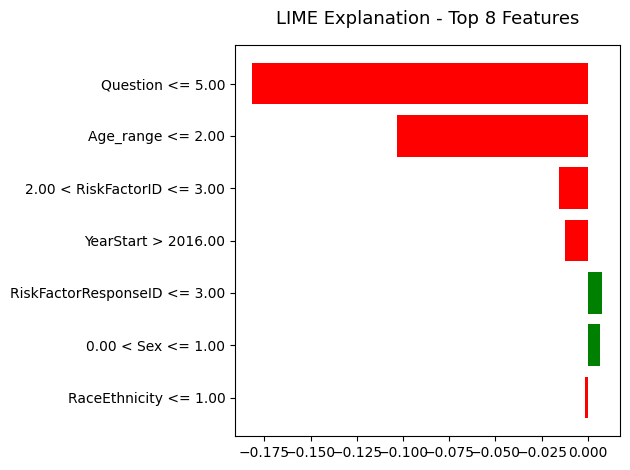

In [189]:
exp.as_pyplot_figure()
plt.title("LIME Explanation - Top 8 Features", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Using the Model

Since XGBoost Classifier had the best performance, lets use that.

In [178]:
ETHNICITY_LABELS = [
    "All races",
    "Asian",
    "Black, non-Hispanic",
    "Hispanic, any race",
    "North American Native",
    "Other",
    "White, non-Hispanic"
]

In [181]:
QUESTION_PROMPTS = [
    "I have been told by a doctor that I have cataracts.",
    "I have been told by a doctor that I have diabetic retinopathy.",
    "I have been told by a doctor that I have glaucoma.",
    "I have been told by a doctor that I have macular degeneration.",
    "I have had cataract surgery.",
    "I am blind or unable to see at all.",
    "I currently wear eyeglasses or contact lenses.",
    "I find it difficult to drive during the daytime in familiar places, even when wearing glasses or contact lenses.",
    "I find it difficult to notice objects off to the side, even when wearing glasses or contact lenses.",
    "I have trouble seeing even when wearing glasses or contact lenses.",
    "In the past 12 months, I have seen or talked to an eye care professional.",
    "I participate in sports or hobbies that could cause eye injury.",
    "I wear eye protection when participating in activities that may cause eye injury.",
    "My child participates in sports or hobbies that could cause eye injury.",
    "My child wears eye protection when participating in sports or hobbies.",
    "My child has trouble seeing even when wearing glasses or contact lenses.",
    "My child is blind or unable to see at all.",
    "My child wears eyeglasses or contact lenses.",
    "I wear glasses."
]

In [182]:
print("\n=== VISUAL IMPAIRMENT RISK ASSESSMENT ===\n")

#  Year
year = int(input("Enter year of visual problem initiation (e.g. 2016): "))

#  Sex
print("\nSex:")
print("0 = Male | 1 = Female | 2 = Both sexes")
sex = int(input("Enter value: "))

#  Ethnicity
print("\nRace / Ethnicity:")
for i, name in enumerate(ETHNICITY_LABELS):
    print(f"{i} → {name}")

race = int(input("Choose race number: "))

#  Eye condition
print("\nVision / Eye Health Questions:")
for i, q in enumerate(QUESTION_PROMPTS):
    print(f"{i} → {q}")

question = int(input("Choose the number that best applies to you: "))

#  Smoking
print("\nSmoking status (RiskFactorResponseID):")
print("4 = No | 5 = Yes | 6 = Never")
smoking = int(input("Enter value: "))

#  Age
print("\nAge range (Age_range):")
print("0=0-17 | 1=18-39 | 2=40-64 | 3=65-84 | 4=85+ | 5=18+ | 6=All")
age_range = int(input("Enter value: "))

# BUILD INPUT ROW

row = {
    "YearStart": year,
    "Sex": sex,
    "RaceEthnicity": race,
    "Question": question,
    "Data_Value": 0.0,
    "RiskFactorID": 3,                 # RFSM
    "RiskFactorResponseID": smoking,
    "Age_range": age_range
}

X_input = pd.DataFrame([row])
X_input = X_input.reindex(columns=feature_cols, fill_value=0)

# PREDICTION
pred = rf_clf.predict(X_input)[0]
probs = rf_clf.predict_proba(X_input)[0]

risk_map = {
    0: "Low risk",
    1: "Moderate risk",
    2: "High risk",
    3: "Very high risk"
}

print("\n===== RESULT =====")
print(f"Predicted visual impairment risk level: {risk_map[pred]}")
print("Class probabilities:", np.round(probs, 3))



=== VISUAL IMPAIRMENT RISK ASSESSMENT ===

Enter year of visual problem initiation (e.g. 2016): 2020

Sex:
0 = Male | 1 = Female | 2 = Both sexes
Enter value: 1

Race / Ethnicity:
0 → All races
1 → Asian
2 → Black, non-Hispanic
3 → Hispanic, any race
4 → North American Native
5 → Other
6 → White, non-Hispanic
Choose race number: 1

Vision / Eye Health Questions:
0 → I have been told by a doctor that I have cataracts.
1 → I have been told by a doctor that I have diabetic retinopathy.
2 → I have been told by a doctor that I have glaucoma.
3 → I have been told by a doctor that I have macular degeneration.
4 → I have had cataract surgery.
5 → I am blind or unable to see at all.
6 → I currently wear eyeglasses or contact lenses.
7 → I find it difficult to drive during the daytime in familiar places, even when wearing glasses or contact lenses.
8 → I find it difficult to notice objects off to the side, even when wearing glasses or contact lenses.
9 → I have trouble seeing even when wearing 

### Saving all the models

In [192]:
import joblib

In [193]:
joblib.dump(logreg_pipeline, "best_logreg_merged.pkl")
joblib.dump(rf_clf, "best_rf_merged.pkl")
joblib.dump(xgb_clf, "best_xgb_merged.pkl")

['best_xgb_merged.pkl']